### MILESTONE 4 - Training Our SECOND Model - PCA, KMeans exploration, XGBoost

### Evaluating the model

The final XGBoost model with num_classes = 19, max_depth = 5, n_estimators = 50, and learning rate 0.3 performs quite well when trained on the PCA-transformed data, scoring .61 F1 on the training set and .60 F1 on the test set.

Like our first model, this model sits is a bit underfit since train and test F1 are close together (small generalization gap), and increasing model complexity continues to help. The problem here here is the data, not the model because genre tags are noisy and many releases span multiple buckets, so there is label uncertainty that challenges the models. 

The scree/cumulative variance plot showed that roughly the first 25–50 components captured 10% of the variance: since the variance is so spread out across thousands of noisy rare tags, this likely captures most of the "important" genre signal. Cumulative explained variance increases linearly with more components, approaching roughly 0.2 with 100 components. 

KMeans silhouette score on the reduced features was modest and weighted cluster purity vs ground truth genres was substantially above the random baseline (1/19 ≈ 5.3%). This indicates that PCA reduced features do separate genres to a meaningful extent in an unsupervised setting.


### Fitting Analysis

As mentioned, our model sits a bit underfit in the fitting graph, though underfitting is slight. There are a couple interesting directions to explore for future improvements: one is adding additional features. The final list of features used in training the model is admittedly pretty scant, being artist gender, area, and the tag vector. A potential missed opportunity was to train on "release year" as a feature, since genre distributions shift massively over time, and this feature was abundant in the data. 

Another idea was to treat this as a multi-label classification problem instead of a single-label classification problem. The XGBoost already uses multi:softprob to generate a probability distribution, so it’s not a huge lift to use, say, top 3 probabilities instead of just the top probability.

Dimensionality reduction had a significant effect on the final training result. Let's take a look at some specifics. For performance: roughly equivalent F1 on a much smaller feature space, demonstrating that most of the genre signal in the tags lies on a low-dimensional manifold within the much larger sparse representation. For efficiency: faster fitting and prediction since the PCA is a one time cost action. For interpretability: harder, as the components are linear combinations of many tags so they don't have direct semantic meaning.


In [28]:
# scale features so each dim has unit var
scaler = StandardScaler(inputCol="features", outputCol="scaled_features", withMean=False, withStd=True)
scaler_model = scaler.fit(final_df)
scaled_df = scaler_model.transform(final_df).select("release_name", "genre_index", "scaled_features").cache()
print(f"scaled feature dim: {scaled_df.first()['scaled_features'].size}")

# fit PCA with k=100 to see var curve before deciding if we need a smaller k
PCA_K_MAX = 100
pca_full = PCA(k=PCA_K_MAX, inputCol="scaled_features", outputCol="pca_features")
pca_full_model = pca_full.fit(scaled_df)

explained_var = np.array(pca_full_model.explainedVariance.toArray())
cum_var = np.cumsum(explained_var)
print(f"Top 5 component variances: {explained_var[:5]}")
print(f"Cumulative @ k=10: {cum_var[9]:.4f}")
print(f"Cumulative @ k=25: {cum_var[24]:.4f}")
print(f"Cumulative @ k=50: {cum_var[49]:.4f}")
print(f"Cumulative @ k=100: {cum_var[-1]:.4f}")

scaled feature dim: 1120
Top 5 component variances: [0.00736503 0.00315891 0.00310716 0.00269844 0.0026651 ]
Cumulative @ k=10: 0.0297
Cumulative @ k=25: 0.0559
Cumulative @ k=50: 0.0926
Cumulative @ k=100: 0.1563


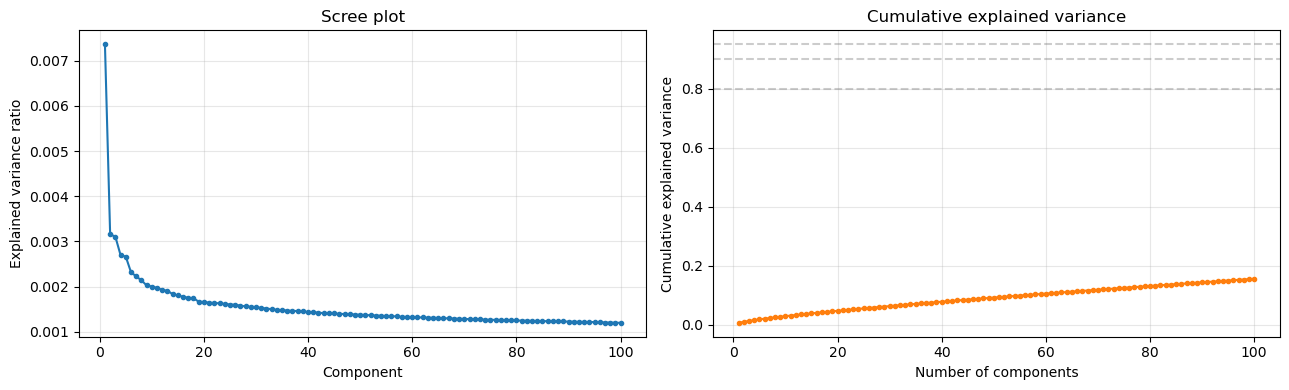

Selected k = 50 (captures 0.093 of variance)


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(range(1, PCA_K_MAX + 1), explained_var, marker='o', markersize=3)
axes[0].set_xlabel("Component"); axes[0].set_ylabel("Explained variance ratio")
axes[0].set_title("Scree plot"); axes[0].grid(alpha=0.3)

axes[1].plot(range(1, PCA_K_MAX + 1), cum_var, marker='o', markersize=3, color='C1')
for thresh in (0.80, 0.90, 0.95):
    axes[1].axhline(thresh, ls='--', alpha=0.4, color='gray')
    k_at = int(np.argmax(cum_var >= thresh)) + 1 if (cum_var >= thresh).any() else None
    if k_at:
        axes[1].axvline(k_at, ls=':', alpha=0.3, color='gray')
        axes[1].text(k_at + 1, thresh - 0.02, f"k={k_at} @ {int(thresh*100)}%", fontsize=9)
axes[1].set_xlabel("Number of components"); axes[1].set_ylabel("Cumulative explained variance")
axes[1].set_title("Cumulative explained variance"); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

# pick smallest k that captures over ~90% variance
target_var = 0.90
PCA_K = int(np.argmax(cum_var >= target_var)) + 1 if (cum_var >= target_var).any() else 50
PCA_K = min(PCA_K, 50)
print(f"Selected k = {PCA_K} (captures {cum_var[PCA_K-1]:.3f} of variance)")

In [30]:
# refitting PCA using the chosen k from above so the whole dataset is transformed into its reduced form
pca = PCA(k=PCA_K, inputCol="scaled_features", outputCol="pca_features")
pca_model = pca.fit(scaled_df)
reduced_df = pca_model.transform(scaled_df).select("release_name", "genre_index", "pca_features").cache()
print(f"Reduced feature dim: {reduced_df.first()['pca_features'].size}")
print(f"Row count: {reduced_df.count():,}")

Reduced feature dim: 50
Row count: 938,482


In [31]:
# start Kmeans clustering on the reduced dataset
# we can use silhouette score to see how well the clusters are identified, thats the next chunk of code

n_clust = 19  # match number of genre buckets

kmeans = KMeans(featuresCol="pca_features", predictionCol="cluster", k=n_clust, seed=42, maxIter=20)
kmeans_model = kmeans.fit(reduced_df)
clustered_df = kmeans_model.transform(reduced_df).cache()

# silhouette score (squared Euclidean — Spark's default for ClusteringEvaluator)
silh_eval = ClusteringEvaluator(featuresCol="pca_features", predictionCol="cluster", metricName="silhouette", distanceMeasure="squaredEuclidean")
silh = silh_eval.evaluate(clustered_df)
print(f"Silhouette score (k={n_clust}): {silh:.4f}")

# cluster purity: in each cluster, what fraction belongs to the majority genre?
purity_df = (clustered_df.groupBy("cluster", "genre_index").count().withColumn("rank", F.row_number().over(Window.partitionBy("cluster").orderBy(F.col("count").desc()))))
top_per_cluster = purity_df.filter(F.col("rank") == 1).select("cluster", "count")
cluster_sizes = clustered_df.groupBy("cluster").count().withColumnRenamed("count", "cluster_size")
purity_joined = top_per_cluster.join(cluster_sizes, "cluster")
total_rows = clustered_df.count()
weighted_purity = (purity_joined.withColumn("contrib", F.col("count").cast("double") / F.lit(total_rows)).agg(F.sum("contrib")).first()[0])

print(f"Weighted cluster purity: {weighted_purity:.4f}")
print(f"(purity = fraction of points whose cluster's majority label matches their true label)")

Silhouette score (k=19): 0.3562
Weighted cluster purity: 0.3442
(purity = fraction of points whose cluster's majority label matches their true label)


  k=  5: silhouette = 0.7920
  k= 10: silhouette = 0.7006
  k= 15: silhouette = 0.4293
  k= 19: silhouette = 0.3562
  k= 25: silhouette = 0.3313
  k= 30: silhouette = 0.2884


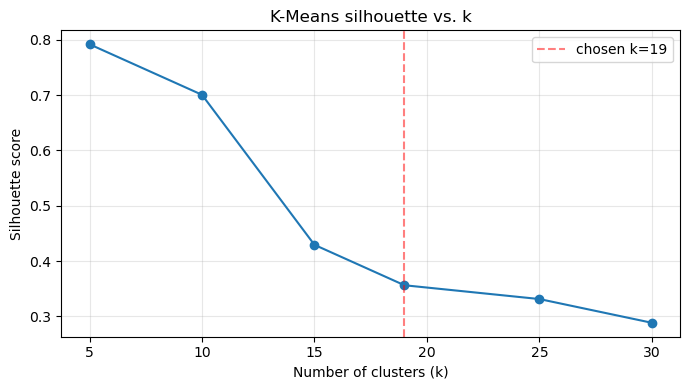

In [32]:
# sweep some k values to see if 19 is the best choice
k_values = [5, 10, 15, 19, 25, 30]
sweep_results = []
for k in k_values:
    km = KMeans(featuresCol="pca_features", predictionCol="cluster", k=k, seed=42, maxIter=20)
    km_model = km.fit(reduced_df)
    out = km_model.transform(reduced_df)
    s = silh_eval.evaluate(out)
    sweep_results.append((k, s))
    print(f"  k={k:3d}: silhouette = {s:.4f}")

ks, ss = zip(*sweep_results)
plt.figure(figsize=(7, 4))
plt.plot(ks, ss, marker='o')
plt.axvline(n_clust, ls='--', alpha=0.5, color='red', label=f'chosen k={n_clust}')
plt.xlabel("Number of clusters (k)"); plt.ylabel("Silhouette score")
plt.title("K-Means silhouette vs. k"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [33]:
# new xgboost model on the PCA reduced features

from xgboost.spark import SparkXGBClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

train_xgb, test_xgb = reduced_df.select(
    "genre_index", 
    "pca_features"
).randomSplit([0.8, 0.2], seed=42)

xgb = SparkXGBClassifier(
    features_col="pca_features",
    label_col="genre_index",
    prediction_col="prediction",
    num_class=19,
    max_depth=5,
    n_estimators=50,
    learning_rate=0.3,
    subsample=0.8,
    colsample_bytree=0.8
)

xgb_model = xgb.fit(train_xgb)

train_xgb_preds = xgb_model.transform(train_xgb)
test_xgb_preds  = xgb_model.transform(test_xgb)

f1_eval = MulticlassClassificationEvaluator(
    labelCol="genre_index",
    predictionCol="prediction",
    metricName="f1"
)

acc_eval = MulticlassClassificationEvaluator(
    labelCol="genre_index",
    predictionCol="prediction",
    metricName="accuracy"
)

train_f1  = f1_eval.evaluate(train_xgb_preds)
test_f1   = f1_eval.evaluate(test_xgb_preds)
train_acc = acc_eval.evaluate(train_xgb_preds)
test_acc  = acc_eval.evaluate(test_xgb_preds)

print(f"\n{'Metric':<20} {'Train':>10} {'Test':>10}")
print(f"{'Accuracy':<20} {train_acc:>10.4f} {test_acc:>10.4f}")
print(f"{'Weighted F1':<20} {train_f1:>10.4f} {test_f1:>10.4f}")

# per-class F1 on test set
label_list_xgb = pipeline_model.stages[0].labels
per_class_ev = MulticlassClassificationEvaluator(
    labelCol="genre_index",
    predictionCol="prediction",
    metricName="fMeasureByLabel"
)
print(f"\n{'Genre Bucket':<40} {'Test F1 (XGBoost)':>18}")
print("-" * 60)
for idx, label in enumerate(label_list_xgb):
    per_class_ev.setMetricLabel(float(idx))
    f1_val = per_class_ev.evaluate(test_xgb_preds)
    print(f"{label:<40} {f1_val:>18.4f}")

2026-05-29 12:27:02,181 INFO XGBoost-PySpark: _fit Running xgboost-2.0.3 on 1 workers with
	booster params: {'objective': 'multi:softprob', 'colsample_bytree': 0.8, 'device': 'cpu', 'learning_rate': 0.3, 'max_depth': 5, 'subsample': 0.8, 'num_class': 19, 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round': 50}
	dmatrix_kwargs: {'nthread': 1, 'missing': nan}
2026-05-29 12:28:56,611 INFO XGBoost-PySpark: _fit Finished xgboost training!



Metric                    Train       Test
Accuracy                 0.6217     0.6143
Weighted F1              0.6110     0.6028

Genre Bucket                              Test F1 (XGBoost)
------------------------------------------------------------
Rock                                                 0.6339
Electronic / Dance                                   0.7264
Pop                                                  0.5561
Jazz                                                 0.6746
Classical / Orchestral / Opera                       0.8358
Hip-Hop / Rap                                        0.6139
Metal                                                0.5749
Experimental / Avant-garde / Noise                   0.3548
Punk / Hardcore / Emo                                0.3575
Folk / Singer-Songwriter                             0.3321
Ambient / New Age                                    0.3364
Country / Americana / Bluegrass                      0.4700
R&B / Soul / Funk           

### Conclusion Section

The final XGBoost model performs well. We can safely say that we have a model that can accurately predict a release's genre using only some metadata, a majority of the time. If we wanted to go further and pursue the ambitious goal we set out in our abstract, which was to build a recommendation system, a model like this would serve as a solid foundation to build on.

This model could still be improved further. One approach worth exploring is an architecture with more rounds (300-500) but a lower learning rate (0.1) and early stopping. An approach like this might give the boosting process finer-grained correction at each step, with the trade-off of taking more time to train. Combining this with an increased maxDepth could push overall performance up by .2-.3.


CORRECT PREDICTIONS: (10 random samples)


,release_name,true_genre,predicted_genre
0,You | me,Jazz,Jazz
1,Pulcinella; Jeu de Cartes,Classical / Orchestral / Opera,Classical / Orchestral / Opera
2,Got to Move Your Body,Electronic / Dance,Electronic / Dance
3,Live in Europe,Blues,Blues
4,Anjunabeach (The Remixes),Electronic / Dance,Electronic / Dance
5,Único Dios (TIMBRO remix),Electronic / Dance,Electronic / Dance
6,Bach 300,Classical / Orchestral / Opera,Classical / Orchestral / Opera
7,Piano Concertos Nos 21 & 23,Classical / Orchestral / Opera,Classical / Orchestral / Opera
8,Beyond the Satellite,Electronic / Dance,Electronic / Dance
9,Nasum / Asterisk,Punk / Hardcore / Emo,Punk / Hardcore / Emo



MISCLASSIFICATIONS: (10 random samples)
(FP for 'predicted_genre' and FN for 'true_genre')


,release_name,true_genre,predicted_genre
0,Red Wine Supernova (magician’s cut),Pop,Rock
1,Навстречу Солнцу И Свету,Electronic / Dance,Rock
2,Old Orchard Beach EP,Experimental / Avant-garde / Noise,Electronic / Dance
3,Hello There Angel / Hitch Hike,R&B / Soul / Funk,Rock
4,Cheap Happiness or Lofty Suffering,Punk / Hardcore / Emo,Rock
5,Weltstorm,Electronic / Dance,Folk / Singer-Songwriter
6,Simpler Times,Jazz,Electronic / Dance
7,Selected Demos & Rarities,Rock,R&B / Soul / Funk
8,LOVE + FEAR,Pop,Rock
9,Bayside '93,Pop,Electronic / Dance



OVERALL SUMMARY:
Test samples:    187,364
Correct:         116,273  (62.1%)
Misclassified:    71,091  (37.9%)

Genre                                       FP count  FN count
--------------------------------------------------------------
Rock                                          26,885    11,298
Electronic / Dance                            13,661     9,316
Pop                                           14,067     9,906
Jazz                                           2,595     4,574
Classical / Orchestral / Opera                   595     2,117
Hip-Hop / Rap                                  1,213     4,097
Metal                                          2,242     3,634
Experimental / Avant-garde / Noise             2,601     5,249
Punk / Hardcore / Emo                            950     3,690
Folk / Singer-Songwriter                       1,293     3,637
Ambient / New Age                                995     3,597
Country / Americana / Bluegrass                  714     2,522
R&B / 

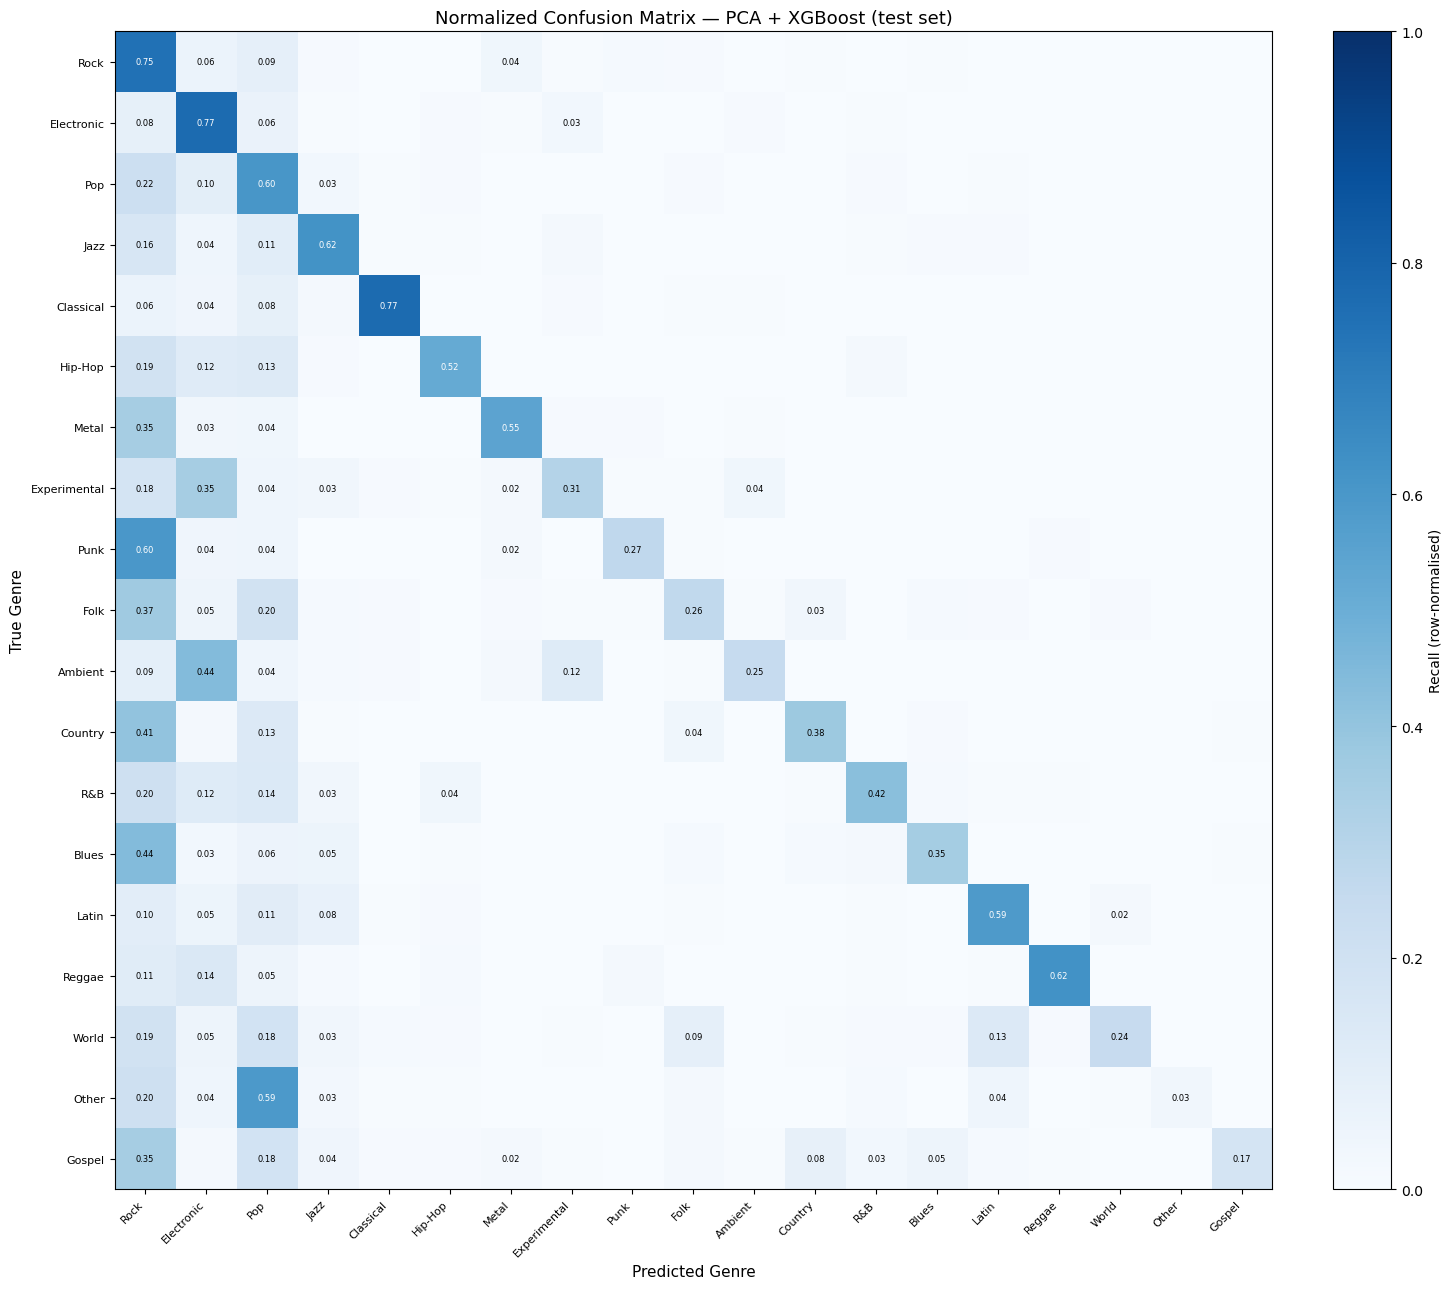

In [36]:
# Predictions Analysis: Correct classifications, FPs, and FNs
# Re-split reduced_df (to include release_name) with the same seed used in training
_, test_named = reduced_df.randomSplit([0.8, 0.2], seed=42)
test_named_preds = xgb_model.transform(test_named)
label_arr = pipeline_model.stages[0].labels

index_to_genre = {float(i): lbl for i, lbl in enumerate(label_arr)}
preds_pd = (test_named_preds.select("release_name", "genre_index", "prediction").toPandas())
preds_pd["true_genre"] = preds_pd["genre_index"].map(index_to_genre)
preds_pd["predicted_genre"] = preds_pd["prediction"].map(index_to_genre)

correct = preds_pd[preds_pd["genre_index"] == preds_pd["prediction"]]
wrong   = preds_pd[preds_pd["genre_index"] != preds_pd["prediction"]]

# Sample rows
print("\nCORRECT PREDICTIONS: (10 random samples)")
display(correct[["release_name", "true_genre", "predicted_genre"]].sample(10, random_state=42).reset_index(drop=True))

print("\nMISCLASSIFICATIONS: (10 random samples)")
print("(FP for 'predicted_genre' and FN for 'true_genre')")
display(wrong[["release_name", "true_genre", "predicted_genre"]].sample(10, random_state=42).reset_index(drop=True))

# Overall summary with per-class FP / FN counts
from collections import Counter

total     = len(preds_pd)
n_correct = len(correct)
print("\nOVERALL SUMMARY:")
print(f"Test samples:   {total:>8,}")
print(f"Correct:        {n_correct:>8,}  ({n_correct / total * 100:.1f}%)")
print(f"Misclassified:  {total - n_correct:>8,}  ({(total - n_correct) / total * 100:.1f}%)")

fp_by_class = Counter(wrong["predicted_genre"])
fn_by_class = Counter(wrong["true_genre"])
print(f"\n{'Genre':<42} {'FP count':>9} {'FN count':>9}")
print("-" * 62)
for lbl in label_arr:
    print(f"{lbl:<42} {fp_by_class.get(lbl, 0):>9,} {fn_by_class.get(lbl, 0):>9,}")

# Normalized confusion matrix heatmap
print()
cm_df = pd.crosstab(preds_pd["true_genre"], preds_pd["predicted_genre"])
cm_df  = cm_df.reindex(index=label_arr, columns=label_arr, fill_value=0)
cm_norm = cm_df.div(cm_df.sum(axis=1), axis=0).fillna(0).values

short = [lbl.split(" / ")[0][:15] for lbl in label_arr]
n     = len(label_arr)

fig, ax = plt.subplots(figsize=(16, 13))
im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Recall (row-normalised)")
ax.set_xticks(range(n)); ax.set_yticks(range(n))
ax.set_xticklabels(short, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(short, fontsize=8)
ax.set_xlabel("Predicted Genre", fontsize=11)
ax.set_ylabel("True Genre", fontsize=11)
ax.set_title("Normalized Confusion Matrix — PCA + XGBoost (test set)", fontsize=13)
for i in range(n):
    for j in range(n):
        v = cm_norm[i, j]
        if v > 0.02:
            ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                    fontsize=6, color="white" if v > 0.5 else "black")
plt.tight_layout()
plt.show()